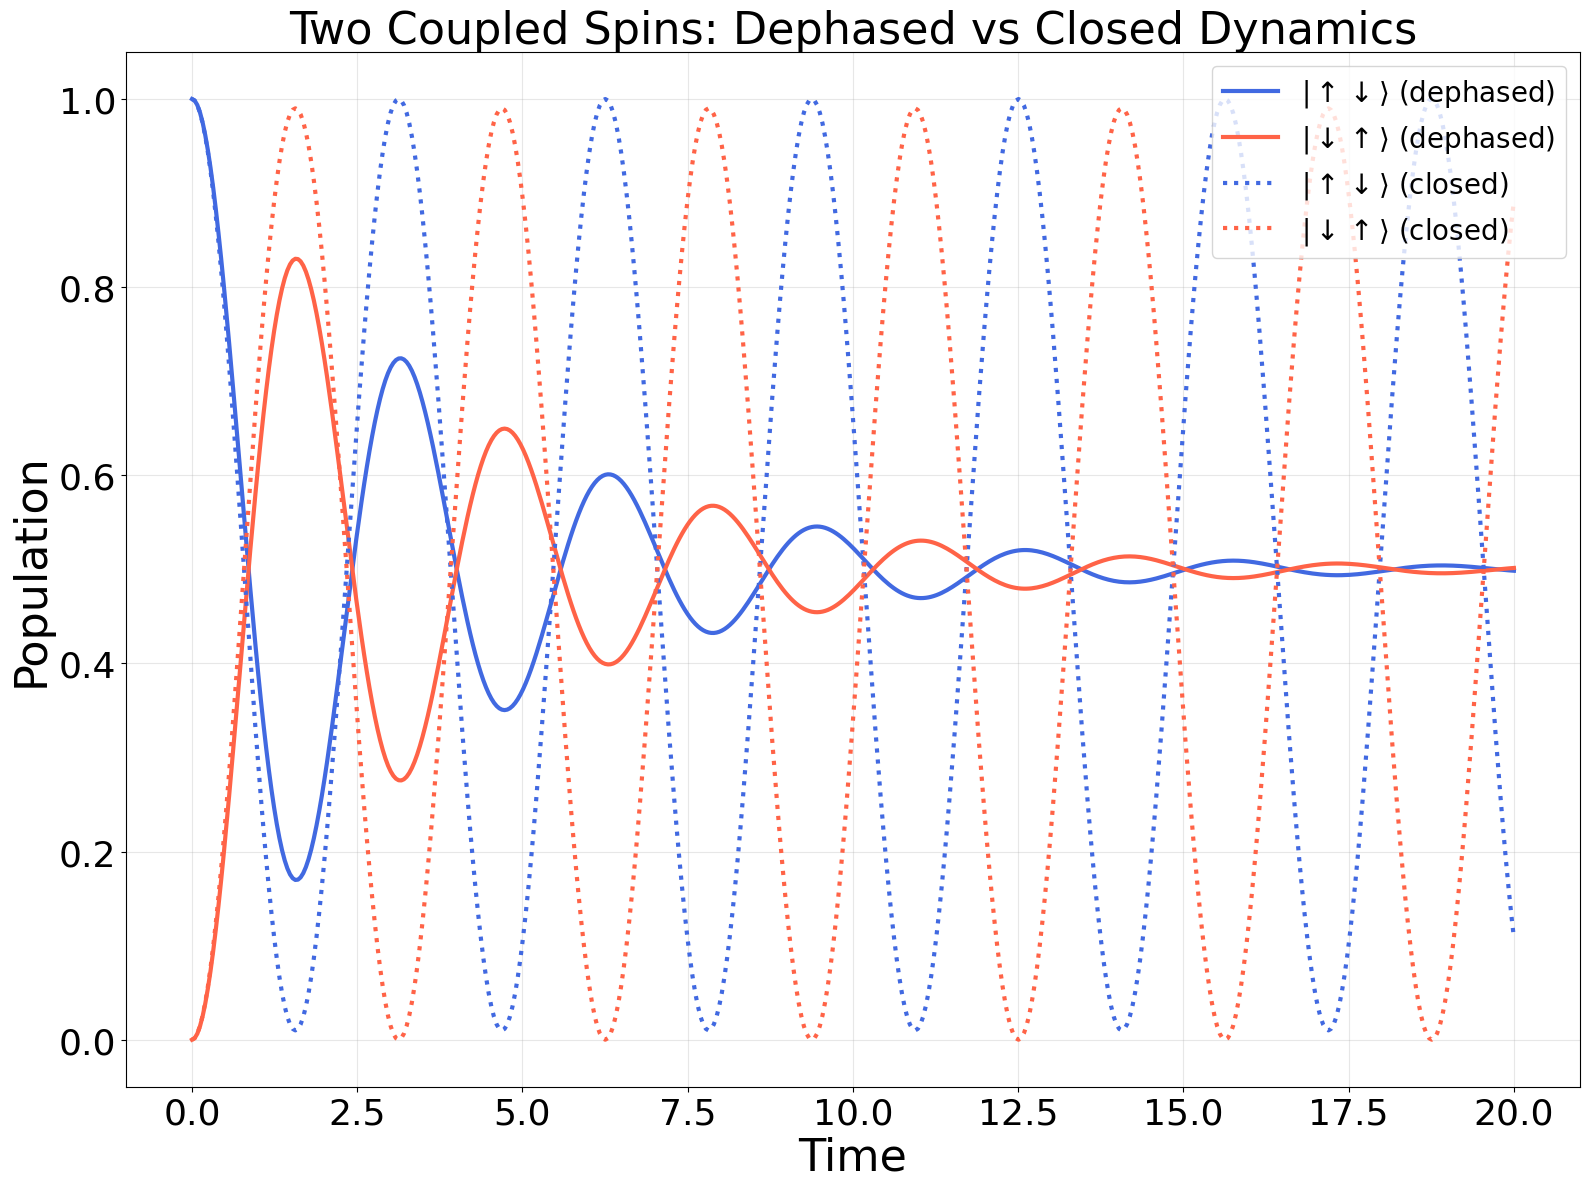

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

# Parameters
omega1 = 1.0
omega2 = 1.2
J = 0.5
gamma1 = 0.1
gamma2 = 0.15
tlist = np.linspace(0, 20, 500)

# Operators
sx1 = qt.tensor(qt.sigmax(), qt.qeye(2))
sy1 = qt.tensor(qt.sigmay(), qt.qeye(2))
sz1 = qt.tensor(qt.sigmaz(), qt.qeye(2))
sx2 = qt.tensor(qt.qeye(2), qt.sigmax())
sy2 = qt.tensor(qt.qeye(2), qt.sigmay())
sz2 = qt.tensor(qt.qeye(2), qt.sigmaz())

# Hamiltonian
H = (omega1 / 2) * sz1 + (omega2 / 2) * sz2 + J * (sx1 * sx2 + sy1 * sy2)

# Collapse operators
c_ops = [np.sqrt(gamma1) * sz1, np.sqrt(gamma2) * sz2]

# Initial state |↑↓⟩
psi0 = qt.tensor(qt.basis(2, 0), qt.basis(2, 1))

# Projectors for |↑↓⟩ and |↓↑⟩
ud = qt.tensor(qt.basis(2, 0), qt.basis(2, 1))
du = qt.tensor(qt.basis(2, 1), qt.basis(2, 0))
proj_ud = ud * ud.dag()
proj_du = du * du.dag()

# Open system (dephasing)
result_open = qt.mesolve(H, psi0, tlist, c_ops, [proj_ud, proj_du])

# Closed system (no dephasing)
result_closed = qt.mesolve(H, psi0, tlist, [], [proj_ud, proj_du])

# Plot
fig, ax = plt.subplots(figsize=(16, 12))

ax.plot(tlist, result_open.expect[0],   color="royalblue", lw=3,   ls="-",  label=r"$|\uparrow\downarrow\rangle$ (dephased)")
ax.plot(tlist, result_open.expect[1],   color="tomato",    lw=3,   ls="-",  label=r"$|\downarrow\uparrow\rangle$ (dephased)")
ax.plot(tlist, result_closed.expect[0], color="royalblue", lw=3, ls=":",  label=r"$|\uparrow\downarrow\rangle$ (closed)")
ax.plot(tlist, result_closed.expect[1], color="tomato",    lw=3, ls=":",  label=r"$|\downarrow\uparrow\rangle$ (closed)")

ax.set_xlabel("Time", fontsize=32)
ax.set_ylabel("Population", fontsize=32)
ax.set_title("Two Coupled Spins: Dephased vs Closed Dynamics", fontsize=32)
ax.legend(fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=26)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()